<a href="https://colab.research.google.com/github/salil82/Module-B-semester-2/blob/main/OMDS-ModB2-Week6-Deshpande-Salil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_23246/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

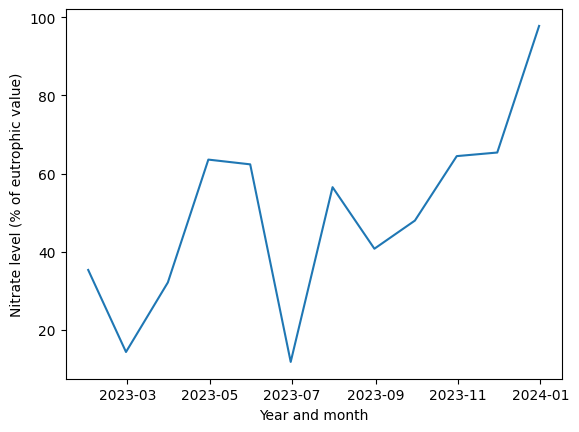

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_23246/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

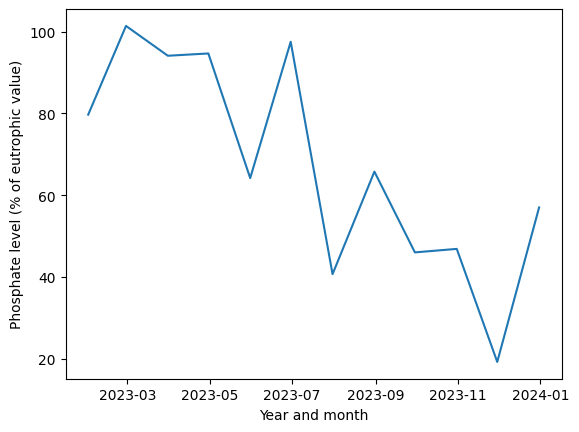

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

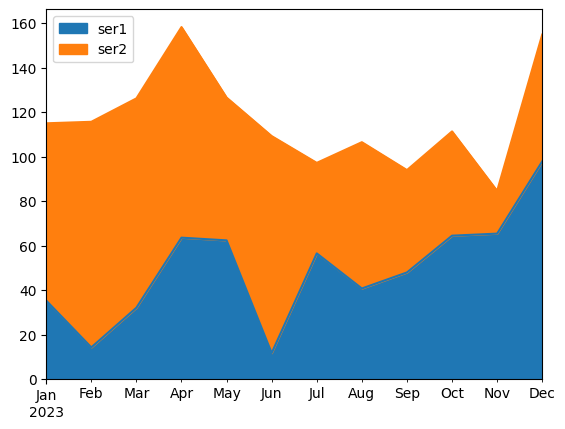

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

The advantages of an area plot are that they show the total combined value of nitrate and phosphate at any given time, highlights the contribution of each component, and shows trends in the cumulative data. However, it can be misleading if the values are not truly additive. I would combine the series into a single graph with distinct lines and a clear legend.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

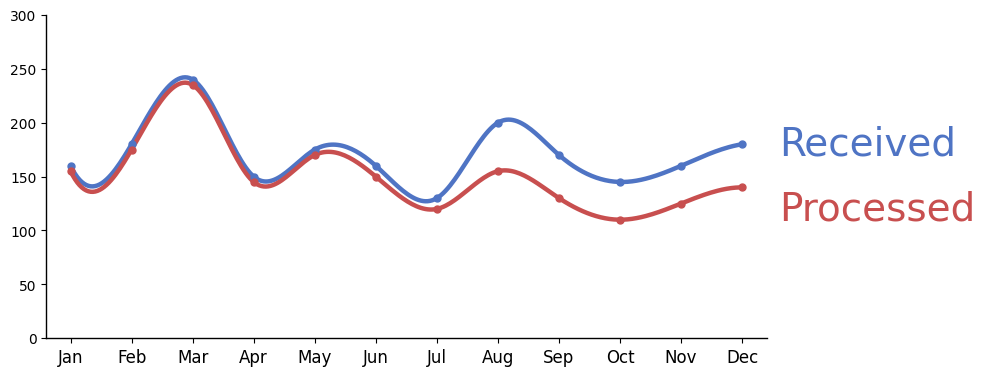

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Data (monthly values). Adjust if you have exact numbers.
months = np.arange(1, 13)
labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

received = np.array([160, 180, 240, 150, 175, 160, 130, 200, 170, 145, 160, 180])
processed = np.array([155, 175, 235, 145, 170, 150, 120, 155, 130, 110, 125, 140])

# For smoother lines, interpolate on a finer x (optional)
x_smooth = np.linspace(months.min(), months.max(), 300)
spline_r = make_interp_spline(months, received, k=3)
spline_p = make_interp_spline(months, processed, k=3)
received_smooth = spline_r(x_smooth)
processed_smooth = spline_p(x_smooth)

# Plot
plt.figure(figsize=(11, 4.2))
ax = plt.gca()

# Plot smooth lines with a bit of linewidth and rounded capstyle
ax.plot(x_smooth, received_smooth, color="#4f74c4", linewidth=3.2, solid_capstyle='round')
ax.plot(x_smooth, processed_smooth, color="#c84f4f", linewidth=3.2, solid_capstyle='round')

# Also plot markers at actual months (optional)
ax.plot(months, received, 'o', color="#4f74c4", markersize=5)
ax.plot(months, processed, 'o', color="#c84f4f", markersize=5)

# Axis limits and ticks
ax.set_xlim(0.6, 12.4)
ax.set_ylim(0, 300)
ax.set_xticks(months)
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks(np.arange(0, 301, 50))
ax.tick_params(axis='y', labelsize=10)

# Light horizontal gridlines (optional)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Remove top and right spines, keep left and bottom thin
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# Place large legend text on the right similar to the image.
# We'll place text annotation aligned with roughly Nov/Dec vertical position.
# Adjust y positions to match the visual.
ax.text(12.6, received_smooth[-1], "Received", color="#4f74c4",
        fontsize=28, va='center', ha='left', fontweight='normal')
ax.text(12.6, processed_smooth[-1] - 20, "Processed", color="#c84f4f",
        fontsize=28, va='center', ha='left', fontweight='normal')

# Remove clipping so text outside axes is visible
ax.set_clip_on(False)

# Tight layout and show
plt.subplots_adjust(right=0.78)  # make space on the right for labels
plt.show()